In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
if os.path.exists('/kaggle/input'):
    path = '/kaggle/input/datasets/osaidali/all-paksiatn-hospitals/Data.csv'
else:
    path = 'Data.csv'
df = pd.read_csv(path)

# EDA

***Overview***

In [3]:
df.head(20)

,Name,CategoryName,Contact Number,City,Address,Website
0,Javed Iqbal Medical Store,Medical Center,NaN,Chitrāl,"Zero point Drosh, Bazar, Chitrāl,",NaN
1,Kausar First Aid & Medical Centre,Hospital,+92 333 3916780,Khuzdar,"Basima - Khuzdar Hwy, Khuzdar,",NaN
2,Rimsa Medical Center,Medical Center,NaN,Dādu,"PQHC+CMC, Police Line Rd, Dādu,",NaN
3,Government Medical Institute of science kidney...,Hospital department,+92 316 3283892,Gambat,"9G2G+394, Gambat, 66070,",NaN
4,Dr Amjad Ali,Hospital,+92 244 360307,Nawabshah,"Chowk, Mohsin Medicare Center, Masjid Rd, near...",NaN
5,Civil Hospital Larkana,Hospital,+92 335 6559909,Larkana,"H636+94G civil hospital, Jail Raod, Larkana,",NaN
6,River City Hospital Sukkur,Hospital,+92 71 5825050,Sukkur,"PRG7+6XF, Imdad Ali Awan Rd, Soarth Memon Hous...",NaN
7,"PAF Hospital, Shahbaz",Hospital,+92 330 3216095,Jacobabad,"7FHH+4V2, Jacobabad,",NaN
8,Red Crescent Hospital Sukkur,Hospital,+92 243 715743,Sukkur,"MVW8+9G4, Sanghi, 65200,",NaN
9,DHQ Hospital Kamber,Government hospital,NaN,Qambar,"HXJW+9XC, Qambar,",NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 693 entries, 0 to 692
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Name            693 non-null    str  
 1   CategoryName    688 non-null    str  
 2   Contact Number  391 non-null    str  
 3   City            668 non-null    str  
 4   Address         693 non-null    str  
 5   Website         83 non-null     str  
dtypes: str(6)
memory usage: 32.6 KB


In [5]:
# CHECK NULLS
df.isnull().sum()

Name                0
CategoryName        5
Contact Number    302
City               25
Address             0
Website           610
dtype: int64

In [6]:
df.describe()

,Name,CategoryName,Contact Number,City,Address,Website
count,693,688,391,668,693,83
unique,646,57,386,282,688,80
top,Hospital,Hospital,+92 800 777 55,Peshawar,"Gojra,",www.siut.org/
freq,18,493,4,50,3,2


**Categorical Analysis**


*preprocessing*

In [7]:
value_counts=df['CategoryName'].value_counts().index
print('--------------------------------')
print('All Values are :\n', value_counts)

value_counts=df['City'].value_counts().index
print('--------------------------------')
print('All Values are :\n', value_counts)

--------------------------------
All Values are :
 Index(['Hospital', 'Government hospital', 'General hospital', 'Medical Center',
       'Private hospital', 'Hospital department', 'Animal hospital',
       'Children's hospital', 'Maternity hospital', 'Medical laboratory',
       'Pharmacy', 'Medical clinic', 'Playground', 'Health consultant',
       'Heart hospital', 'Community center', 'Local medical services',
       'General store', 'Community health center', 'Laboratory',
       'Dental clinic', 'Mosque', 'University', 'Vetenary Hospital ',
       'Diagnostic center', 'Car factory', 'Veterans hospital',
       'Housing society', 'Construction company', 'Blood bank', 'Lodge',
       'Public health department', 'Warehouse', 'Specialized hospital',
       'College', 'Military hospital', 'Bus stop', 'Parking lot',
       'Eye care center', 'Rehabilitation center', 'Child health care center',
       'Addiction treatment center', 'Ophthalmology clinic',
       'Cancer treatment center',

In [8]:

frequent_categories = df['CategoryName'].value_counts().head(10)
print('frequent_categories are :\n', frequent_categories)

print('--------------------------------')
frequent_cities = df['City'].value_counts().head(20)
print('frequent_cities are :\n', frequent_cities)

frequent_categories are :
 CategoryName
Hospital               493
Government hospital     40
General hospital        22
Medical Center          18
Private hospital        15
Hospital department     14
Animal hospital          9
Children's hospital      6
Maternity hospital       4
Medical laboratory       4
Name: count, dtype: int64
--------------------------------
frequent_cities are :
 City
Peshawar           50
Multan             32
Lahore             27
Sukkur             21
Larkana            15
Bahawalpur         13
Bhakkar            12
Khairpur           11
Saidu Sharif       11
Khuzdar            10
Dera Ghazi Khan    10
Mardan              9
Faisalabad          9
Sahiwal             7
Gambat              6
Topi                6
Layyah              6
Gojra               6
Muzaffargarh        6
Dādu                5
Name: count, dtype: int64


**Visualization**

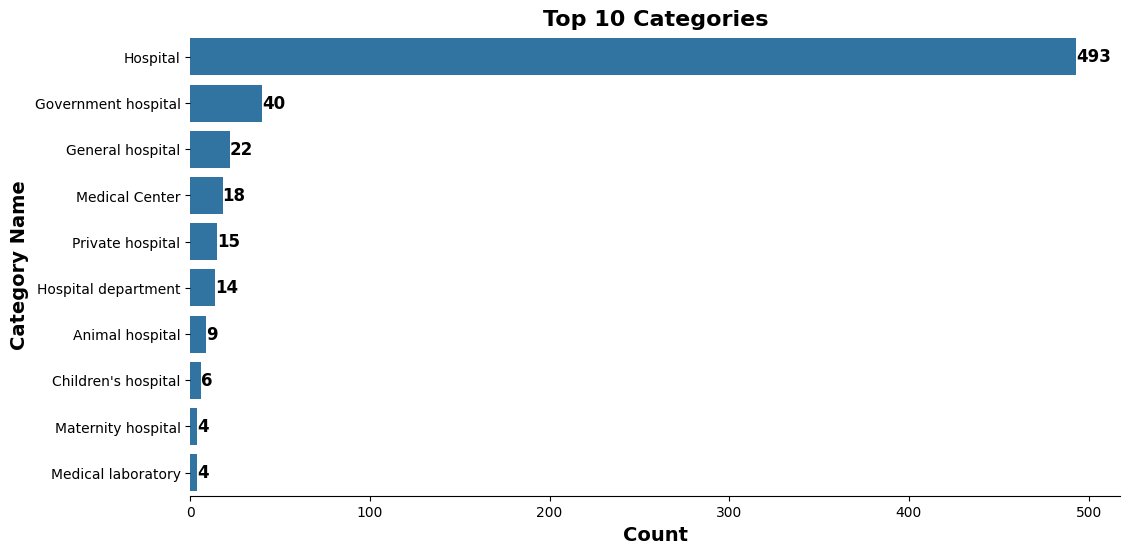

In [9]:
#set figuresize
plt.figure(figsize=(12,6))
frequent_index = frequent_categories.index

ax =sns.countplot(y='CategoryName',
              data=df,
              order=frequent_index,
              )
# for Labeling the bars
for container in ax.containers:
    ax.bar_label(container, fontweight='bold',fontsize=12)

#Remove top and bottom spines
sns.despine(left=True)
plt.title('Top 10 Categories',fontweight='bold',fontsize=16)
plt.xlabel('Count', fontweight='bold',fontsize=14)
plt.ylabel('Category Name',fontweight='bold',fontsize=14)
plt.show()

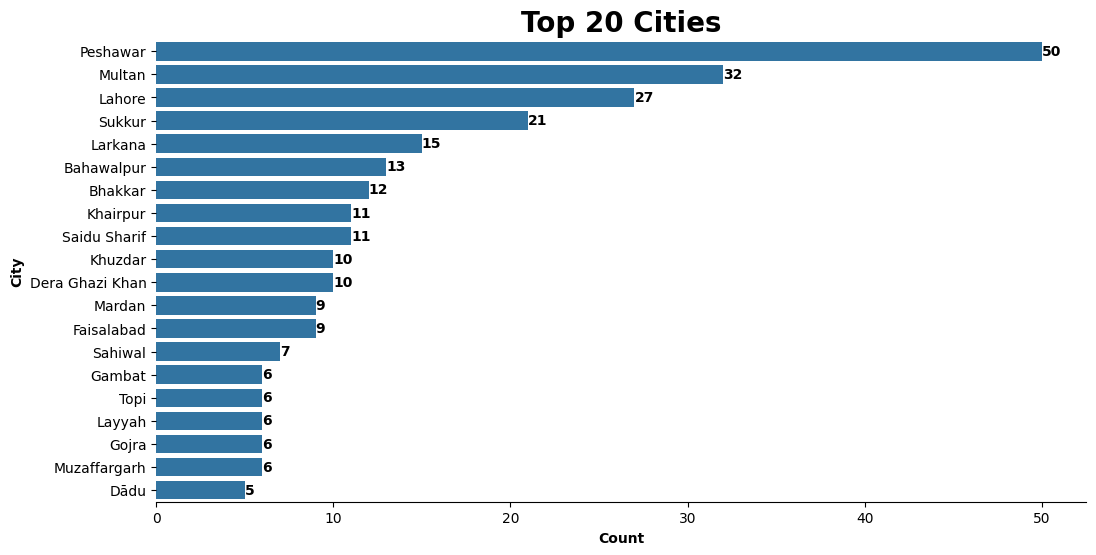

In [10]:
#set figuresize
plt.figure(figsize=(12,6))
frequent_index = frequent_cities.index

ax =sns.countplot(y='City',
              data=df,
              order=frequent_index,
              
              )
# for Labeling the bars
for container in ax.containers:
    ax.bar_label(container, fontweight='bold')

#Remove top and bottom spines
sns.despine(left=True)
plt.title('Top 20 Cities',fontweight='bold',fontsize=20)
plt.xlabel('Count', fontweight='bold')
plt.ylabel('City',fontweight='bold')
plt.show()

# For Number

In [11]:
num_df =df['Contact Number']
num_df.head()

0                NaN
1    +92 333 3916780
2                NaN
3    +92 316 3283892
4     +92 244 360307
Name: Contact Number, dtype: str

In [20]:
# ^ ensures it only replaces at the start of the string
# regex=True is required for using the '^' symbol
df1 = df['Contact Number'].str.replace(r'^\+92', '0', regex=True)
df1 = df1.str.replace(" ",'',regex=False)
    
print(df1.head(6))

# Check length of the cleaned contact numbers
lengths = df1.str.len()
print(lengths)

0            NaN
1    03333916780
2            NaN
3    03163283892
4     0244360307
5    03356559909
Name: Contact Number, dtype: str
0       NaN
1      11.0
2       NaN
3      11.0
4      10.0
       ... 
688     NaN
689     NaN
690     NaN
691     NaN
692    11.0
Name: Contact Number, Length: 693, dtype: float64


In [21]:
valid_numbers = df1[df1.str.len() == 11]
invalid_numbers = df1[(df1.str.len() != 11) & (df1.str.strip() != "")]

print(f"Valid entries: {len(valid_numbers)}")
print(f"Invalid entries: {len(invalid_numbers)}")


Valid entries: 255
Invalid entries: 438
